In [5]:
import glob
import os
import librosa
import numpy as np

# Path to the metadata file
metadata_file_path = r'D:\download\Compressed\DF-keys-full\keys\DF\CM\trial_metadata.txt'

# Dictionary to hold file identifiers and labels
labels = {}

# Open and read the metadata file
with open(metadata_file_path, 'r') as f:
    for line in f:
        parts = line.strip().split()
        file_identifier = parts[1]  # Example: DF_E_2000011
        label = parts[5]            # Example: "spoof"
        labels[file_identifier] = label

# Directory containing the undersampled audio files
undersampled_audio_dir = r'D:\audio_files\undersampled_audio'

# Find all .flac files in the undersampled directory
audio_files = glob.glob(os.path.join(undersampled_audio_dir, '*.flac'))

# Create a list to store only those files that have corresponding labels in the metadata
valid_audio_files = []
valid_labels = []

# Loop through the audio files and match with metadata labels
for audio_file in audio_files:
    file_name = os.path.basename(audio_file)
    file_identifier = file_name.split('.')[0]  # Extract the file identifier (before the extension)

    # Check if the file identifier exists in the metadata labels
    if file_identifier in labels:
        valid_audio_files.append(audio_file)  # Keep this audio file
        valid_labels.append(labels[file_identifier])  # Store the corresponding label (spoof/bonafide)

# Print the number of matching files
print(f"Found {len(valid_audio_files)} audio files with corresponding labels.")

# Audio to MFCC conversion function
def audio_to_mfcc(audio_file, sr=22050, n_mfcc=13):
    """Convert audio to MFCC."""
    audio, sample_rate = librosa.load(audio_file, sr=sr)
    mfcc = librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=n_mfcc)
    return mfcc

# Function to pad or truncate MFCC to a fixed sequence length
def pad_or_truncate(mfcc, max_time_steps=400):
    """Ensure all MFCCs have the same time dimension by padding or truncating."""
    if mfcc.shape[1] > max_time_steps:  # Truncate if longer
        return mfcc[:, :max_time_steps]
    elif mfcc.shape[1] < max_time_steps:  # Pad with zeros if shorter
        padding = max_time_steps - mfcc.shape[1]
        return np.pad(mfcc, ((0, 0), (0, padding)), mode='constant')
    return mfcc

# Preprocessing the audio files for RNN input
def preprocess_audio_files_rnn(audio_files, labels, n_mfcc=13, max_time_steps=400):
    """Convert audio files to MFCCs, normalize, and prepare for RNN."""
    mfcc_data = []
    label_data = []

    for audio_file, label in zip(audio_files, labels):
        mfcc = audio_to_mfcc(audio_file, n_mfcc=n_mfcc)  # Extract MFCC
        mfcc = pad_or_truncate(mfcc, max_time_steps=max_time_steps)  # Pad/truncate
        mfcc = mfcc.T  # Transpose to shape (time_steps, n_mfcc)

        # Normalize
        max_value = np.max(mfcc)
        if max_value > 0:
            mfcc = mfcc / max_value

        mfcc_data.append(mfcc)
        label_data.append(1 if label == 'spoof' else 0)  # Binary label

    return np.array(mfcc_data), np.array(label_data)

# Preprocess the valid audio files and labels
X, y = preprocess_audio_files_rnn(valid_audio_files, valid_labels, n_mfcc=13, max_time_steps=400)

# RNN-ready data shape
print(f"Shape of X: {X.shape}")  # Should be (num_samples, max_time_steps, n_mfcc)
print(f"Shape of y: {y.shape}")  # Should be (num_samples,)


Found 45234 audio files with corresponding labels.
Shape of X: (45234, 400, 13)
Shape of y: (45234,)


In [6]:
# Stratified 80:20 train-test split
def stratified_split_70_30(X, y, test_size=0.2, random_state=42):
    """Split dataset into stratified 70/30 sets."""
    strat_split = StratifiedShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)
    
    for train_idx, test_idx in strat_split.split(X, y):
        X_train, y_train = X[train_idx], y[train_idx]
        X_test, y_test = X[test_idx], y[test_idx]
    
    # Ensure that the training set has balanced classes
    class_counts = np.bincount(y_train)
    min_class_count = min(class_counts)
    spoof_indices = np.where(y_train == 1)[0][:min_class_count]
    bonafide_indices = np.where(y_train == 0)[0][:min_class_count]
    balanced_train_indices = np.concatenate([spoof_indices, bonafide_indices])
    X_train_balanced, y_train_balanced = X_train[balanced_train_indices], y_train[balanced_train_indices]

    return X_train_balanced, X_test, y_train_balanced, y_test

# Perform the stratified 80/30 split
X_train, X_test, y_train, y_test = stratified_split_70_30(X, y, test_size=0.2, random_state=42)

# Print the distribution of classes to verify stratification
print(f"Training set distribution: {np.bincount(y_train)}")
print(f"Test set distribution: {np.bincount(y_test)}")

Training set distribution: [18093 18093]
Test set distribution: [4524 4523]


In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix


# RNN Model Definition
def build_rnn_model(input_shape):
    model = Sequential()
    
    # First LSTM layer
    model.add(LSTM(64, return_sequences=True, input_shape=input_shape, activation='tanh'))
    model.add(Dropout(0.3))
    model.add(BatchNormalization())
    
    # Second LSTM layer
    model.add(LSTM(32, return_sequences=False, activation='tanh'))
    model.add(Dropout(0.3))
    model.add(BatchNormalization())
    
    # Dense layer
    model.add(Dense(16, activation='relu'))
    model.add(Dropout(0.3))
    
    # Output layer
    model.add(Dense(1, activation='sigmoid'))  # Binary classification
    
    return model

# Input shape for the model
input_shape = (X_train.shape[1], X_train.shape[2])  # (time_steps, n_mfcc)

# Build the model
rnn_model = build_rnn_model(input_shape)

# Compile the model
rnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Display the model summary
rnn_model.summary()

# Early stopping to prevent overfitting
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train the model
history = rnn_model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=128,
    callbacks=[early_stopping],
    verbose=1
)

# Evaluate the model
test_loss, test_accuracy = rnn_model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

# Predictions and classification report
y_pred = (rnn_model.predict(X_test) > 0.5).astype(int).flatten()
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(conf_matrix)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 400, 64)        │        19,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 400, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 400, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,313 (130.13 KB)

 Trainable params: 33,121 (129.38 KB)

 Non-trainable params: 192 (768.00 B)

Epoch 1/50
227/227 ━━━━━━━━━━━━━━━━━━━━ 166s 699ms/step - accuracy: 0.4960 - loss: 0.7557 - val_accuracy: 0.5051 - val_loss: 0.6931
Epoch 2/50
227/227 ━━━━━━━━━━━━━━━━━━━━ 163s 717ms/step - accuracy: 0.4994 - loss: 0.7011 - val_accuracy: 0.4950 - val_loss: 0.6932
Epoch 3/50
227/227 ━━━━━━━━━━━━━━━━━━━━ 159s 699ms/step - accuracy: 0.5018 - loss: 0.6974 - val_accuracy: 0.5048 - val_loss: 0.6933
Epoch 4/50
227/227 ━━━━━━━━━━━━━━━━━━━━ 158s 697ms/step - accuracy: 0.5036 - loss: 0.6950 - val_accuracy: 0.4954 - val_loss: 0.6929
Epoch 5/50
227/227 ━━━━━━━━━━━━━━━━━━━━ 160s 706ms/step - accuracy: 0.4991 - loss: 0.6939 - val_accuracy: 0.4952 - val_loss: 0.6933
Epoch 6/50
227/227 ━━━━━━━━━━━━━━━━━━━━ 161s 707ms/step - accuracy: 0.5047 - loss: 0.6932 - val_accuracy: 0.4952 - val_loss: 0.6932
Epoch 7/50
227/227 ━━━━━━━━━━━━━━━━━━━━ 161s 709ms/step - accuracy: 0.5022 - loss: 0.6943 - val_accuracy: 0.4952 - val_loss: 0.6931
Epoch 8/50
227/227 ━━━━━━━━━━━━━━━━━━━━ 162s 714ms/step - accuracy: 0.4973 -

In [10]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
from sklearn.metrics import precision_score, recall_score, f1_score

# Predict the probability scores on the test set
y_pred_prob = model.predict(X_test).ravel()  # Flatten the array for binary classification
y_pred_class = (y_pred_prob >= 0.5).astype(int)   # Convert probabilities to binary classes (0 or 1)

# Compute the confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred_class)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=['Bonafide', 'Spoof'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

# Compute precision, recall, and F1 score
precision = precision_score(y_test, y_pred_class)
recall = recall_score(y_test, y_pred_class)
f1 = f1_score(y_test, y_pred_class)

# Print precision, recall, and F1 score
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")

# Compute the ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # Diagonal line for random guessing
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()


NameError: name 'model' is not defined

In [1]:
import glob
import os
import librosa
import numpy as np
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import StandardScaler

# Path to the metadata file
metadata_file_path = r'D:\download\Compressed\DF-keys-full\keys\DF\CM\trial_metadata.txt'

# Dictionary to hold file identifiers and labels
labels = {}
with open(metadata_file_path, 'r') as f:
    for line in f:
        parts = line.strip().split()
        file_identifier = parts[1]
        label = parts[5]
        labels[file_identifier] = label

# Directory containing the undersampled audio files
undersampled_audio_dir = r'D:\audio_files\undersampled_audio'
audio_files = glob.glob(os.path.join(undersampled_audio_dir, '*.flac'))

valid_audio_files = []
valid_labels = []

for audio_file in audio_files:
    file_name = os.path.basename(audio_file)
    file_identifier = file_name.split('.')[0]
    if file_identifier in labels:
        valid_audio_files.append(audio_file)
        valid_labels.append(labels[file_identifier])

print(f"Found {len(valid_audio_files)} audio files with corresponding labels.")

# Audio to MFCC conversion function
def audio_to_mfcc(audio_file, sr=22050, n_mfcc=13):
    audio, sample_rate = librosa.load(audio_file, sr=sr)
    mfcc = librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=n_mfcc)
    return mfcc

def pad_or_truncate(mfcc, max_time_steps=400):
    if mfcc.shape[1] > max_time_steps:
        return mfcc[:, :max_time_steps]
    elif mfcc.shape[1] < max_time_steps:
        padding = max_time_steps - mfcc.shape[1]
        return np.pad(mfcc, ((0, 0), (0, padding)), mode='constant')
    return mfcc

# Preprocessing function with normalization
def preprocess_audio_files_rnn(audio_files, labels, n_mfcc=13, max_time_steps=400):
    mfcc_data = []
    label_data = []
    scaler = StandardScaler()
    
    for audio_file, label in zip(audio_files, labels):
        mfcc = audio_to_mfcc(audio_file, n_mfcc=n_mfcc)
        mfcc = pad_or_truncate(mfcc, max_time_steps=max_time_steps).T
        mfcc = scaler.fit_transform(mfcc)
        mfcc_data.append(mfcc)
        label_data.append(1 if label == 'spoof' else 0)

    return np.array(mfcc_data), np.array(label_data)

X, y = preprocess_audio_files_rnn(valid_audio_files, valid_labels)
print(f"Shape of X: {X.shape}")
print(f"Shape of y: {y.shape}")

def stratified_split_70_30(X, y, test_size=0.2, random_state=42):
    strat_split = StratifiedShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)
    for train_idx, test_idx in strat_split.split(X, y):
        X_train, y_train = X[train_idx], y[train_idx]
        X_test, y_test = X[test_idx], y[test_idx]
    return X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = stratified_split_70_30(X, y)
print(f"Training set distribution: {np.bincount(y_train)}")
print(f"Test set distribution: {np.bincount(y_test)}")

def build_rnn_model(input_shape):
    model = Sequential([
        Input(shape=input_shape),
        LSTM(128, return_sequences=True, activation='tanh'),
        Dropout(0.3),
        BatchNormalization(),
        LSTM(64, return_sequences=True, activation='tanh'),
        Dropout(0.3),
        BatchNormalization(),
        LSTM(32, activation='tanh'),
        Dropout(0.3),
        Dense(32, activation='relu'),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])
    return model

input_shape = (X_train.shape[1], X_train.shape[2])
rnn_model = build_rnn_model(input_shape)
rnn_model.compile(optimizer=Adam(learning_rate=0.0001), loss='binary_crossentropy', metrics=['accuracy'])

early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = rnn_model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=64,
    callbacks=[early_stopping],
    verbose=1
)

test_loss, test_accuracy = rnn_model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

y_pred = (rnn_model.predict(X_test) > 0.5).astype(int).flatten()
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

conf_matrix = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(conf_matrix)


Found 45234 audio files with corresponding labels.
Shape of X: (45234, 400, 13)
Shape of y: (45234,)
Training set distribution: [18093 18094]
Test set distribution: [4524 4523]
Epoch 1/50
453/453 ━━━━━━━━━━━━━━━━━━━━ 711s 2s/step - accuracy: 0.6676 - loss: 0.6137 - val_accuracy: 0.7526 - val_loss: 0.5213
Epoch 2/50
453/453 ━━━━━━━━━━━━━━━━━━━━ 746s 2s/step - accuracy: 0.7610 - loss: 0.5165 - val_accuracy: 0.7807 - val_loss: 0.4733
Epoch 3/50
453/453 ━━━━━━━━━━━━━━━━━━━━ 760s 2s/step - accuracy: 0.7713 - loss: 0.4977 - val_accuracy: 0.7876 - val_loss: 0.4580
Epoch 4/50
453/453 ━━━━━━━━━━━━━━━━━━━━ 787s 2s/step - accuracy: 0.7782 - loss: 0.4787 - val_accuracy: 0.7933 - val_loss: 0.4520
Epoch 5/50
453/453 ━━━━━━━━━━━━━━━━━━━━ 767s 2s/step - accuracy: 0.7810 - loss: 0.4714 - val_accuracy: 0.7977 - val_loss: 0.4426
Epoch 6/50
453/453 ━━━━━━━━━━━━━━━━━━━━ 756s 2s/step - accuracy: 0.7863 - loss: 0.4608 - val_accuracy: 0.7972 - val_loss: 0.4373
Epoch 7/50
453/453 ━━━━━━━━━━━━━━━━━━━━ 803s 2s/s

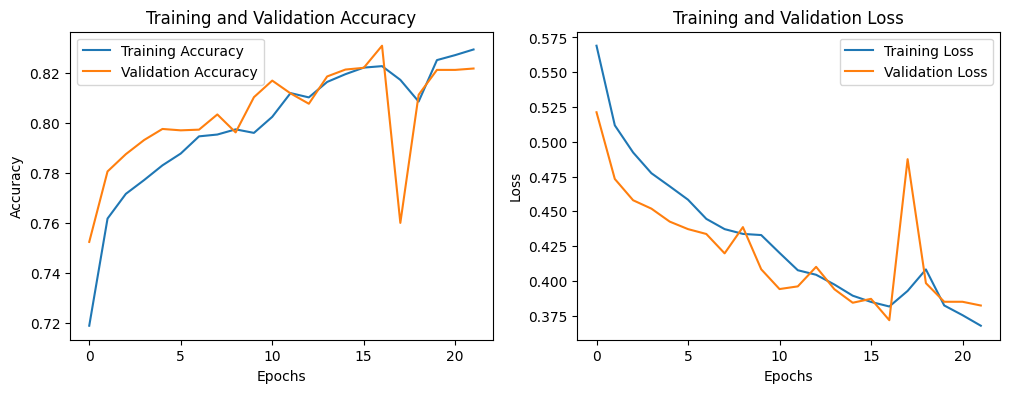

283/283 ━━━━━━━━━━━━━━━━━━━━ 82s 289ms/step


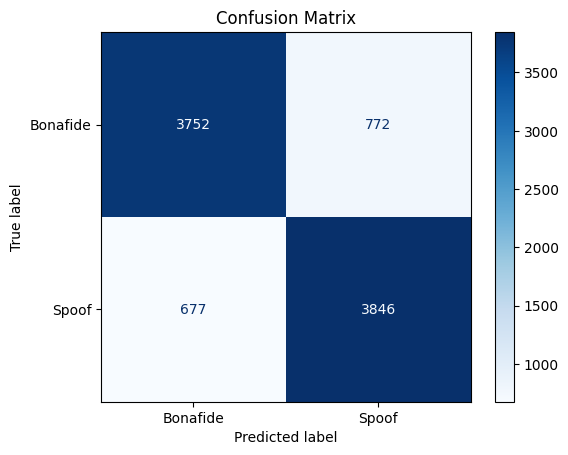

Precision: 0.83
Recall: 0.85
F1 Score: 0.84


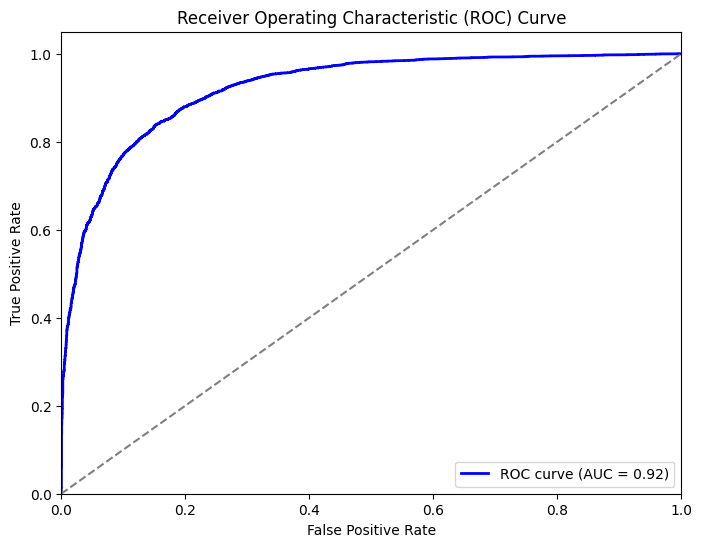

In [5]:
import matplotlib.pyplot as plt
# Plot training & validation accuracy and loss
plt.figure(figsize=(12, 4))

# Plot accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
from sklearn.metrics import precision_score, recall_score, f1_score

# Predict the probability scores on the test set
y_pred_prob = rnn_model.predict(X_test).ravel()  # Flatten the array for binary classification
y_pred_class = (y_pred_prob >= 0.5).astype(int)   # Convert probabilities to binary classes (0 or 1)

# Compute the confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred_class)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=['Bonafide', 'Spoof'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

# Compute precision, recall, and F1 score
precision = precision_score(y_test, y_pred_class)
recall = recall_score(y_test, y_pred_class)
f1 = f1_score(y_test, y_pred_class)

# Print precision, recall, and F1 score
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")

# Compute the ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # Diagonal line for random guessing
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()


In [6]:
from tensorflow.python.client import device_lib

# List available devices
print(device_lib.list_local_devices())


[name: "/device:CPU:0"
device_type: "CPU"
memory_limit: 268435456
locality {
}
incarnation: 3659882546343786408
xla_global_id: -1
]


In [15]:
import tensorflow as tf

# Check if GPU is available
if tf.config.list_physical_devices('GPU'):
    print("GPU is available and being used!")
    print(tf.config.list_physical_devices('GPU'))
else:
    print("GPU is not available, using CPU instead.")


GPU is not available, using CPU instead.


In [12]:
import tensorflow as tf
import torch

print("TensorFlow CUDA support:", tf.test.is_built_with_cuda())
print("Available GPUs for TensorFlow:", tf.config.list_physical_devices('GPU'))

print("PyTorch CUDA available:", torch.cuda.is_available())
print("PyTorch CUDA version:", torch.version.cuda)
print("PyTorch cuDNN version:", torch.backends.cudnn.version())


TensorFlow CUDA support: False
Available GPUs for TensorFlow: []
PyTorch CUDA available: False
PyTorch CUDA version: None
PyTorch cuDNN version: None


In [11]:
!pip install torch

   ---------------------------------------- 0.0/203.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/203.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/203.0 MB ? eta -:--:--
   ---------------------------------------- 0.5/203.0 MB 1.2 MB/s eta 0:02:50
   ---------------------------------------- 0.8/203.0 MB 958.5 kB/s eta 0:03:32
   ---------------------------------------- 0.8/203.0 MB 958.5 kB/s eta 0:03:32
   ---------------------------------------- 1.0/203.0 MB 882.6 kB/s eta 0:03:49
   ---------------------------------------- 1.3/203.0 MB 906.3 kB/s eta 0:03:43
   ---------------------------------------- 1.6/203.0 MB 931.6 kB/s eta 0:03:37
   ---------------------------------------- 1.8/203.0 MB 967.9 kB/s eta 0:03:28
   ---------------------------------------- 2.1/203.0 MB 978.7 kB/s eta 0:03:26
   ---------------------------------------- 2.1/203.0 MB 978.7 kB/s eta 0:03:26
   ---------------------------------------- 2.4/203.0 MB 972.3 kB/s e


[notice] A new release of pip is available: 24.2 -> 24.3.1
[notice] To update, run: python.exe -m pip install --upgrade pip



   - -------------------------------------- 7.1/203.0 MB 829.3 kB/s eta 0:03:57
   - -------------------------------------- 7.3/203.0 MB 832.7 kB/s eta 0:03:56
   - -------------------------------------- 7.6/203.0 MB 840.3 kB/s eta 0:03:53
   - -------------------------------------- 7.6/203.0 MB 840.3 kB/s eta 0:03:53
   - -------------------------------------- 7.9/203.0 MB 838.8 kB/s eta 0:03:53
   - -------------------------------------- 7.9/203.0 MB 838.8 kB/s eta 0:03:53
   - -------------------------------------- 8.1/203.0 MB 826.4 kB/s eta 0:03:56
   - -------------------------------------- 8.4/203.0 MB 832.1 kB/s eta 0:03:54
   - -------------------------------------- 8.7/203.0 MB 838.9 kB/s eta 0:03:52
   - -------------------------------------- 8.7/203.0 MB 838.9 kB/s eta 0:03:52
   - -------------------------------------- 8.7/203.0 MB 838.9 kB/s eta 0:03:52
   - -------------------------------------- 8.9/203.0 MB 813.0 kB/s eta 0:03:59
   - ----------------------------------

In [3]:
pip install tensorflow --upgrade



[notice] A new release of pip is available: 24.2 -> 24.3.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
import tensorflow as tf
print("CUDA Version:", tf.sysconfig.get_build_info()["cuda_version"])


KeyError: 'cuda_version'